# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**

## 1. Team

| Role | Name |
|------|------|
| Lead |Rohit Stanly |
| Member |Armaan Mistry |
| Member |Christy Johns|

## 2. Mission Title & Research Question

**Title:** Renewable Uncertainty and Electricity Market Regimes: Causal Estimation and Prediction of Price Volatility in Germany (2023–2024)

---

**Research question:**

> *To what extent do wind and solar generation forecast errors causally drive day-ahead electricity price deviations in Germany, can a machine learning model predict the magnitude of those deviations one hour ahead, and do distinct grid stress regimes — identifiable through unsupervised clustering — explain the heterogeneity in how forecast errors translate into price outcomes?*

---

**Why it matters:**

Germany's *Energiewende* has pushed the renewable share of electricity generation above 40% on  annual average basis, with individual hours approaching 100% renewable coverage. While this is a necessary transition, it introduces a severe structural challenge: weather-dependent generation cannot be controlled—it can only be forecast. Because wholesale day-ahead auctions clear 12 to 36 hours before physical delivery, the entire financial market operates under intense meteorological uncertainty. When weather forecasts fluctuate or signal high unpredictability, market participants must aggressively price in this structural risk during the day-ahead auction, driving sharp deviations and extreme spreads within the day-ahead price itself.

These day-ahead price deviations carry direct economic costs. Large industrial consumers face severe budgeting and forecasting challenges when day-ahead price volatility spikes. Conversely, extreme negative price blocks—caused by anticipated renewable oversupply—destroy financial value for clean energy generators and signal systemic grid inflexibility. Understanding whether renewable forecast errors *causally* drive these day-ahead price spreads, and being able to *predict* these market stress regimes in advance, has immediate relevance for industrial energy procurement, algorithmic power trading, and renewable integration policy design..

## 3. Data

**Source(s):** All data was extracted via the official **ENTSO-E Transparency Platform via an API key** (European Network of Transmission System Operators for Electricity). The data is open-source and conforms to the European Union's transparency regulations.

**Unit of observation:** One row represents a **15-minute continuous settlement block** in the DE-LU (Germany-Luxembourg) bidding zone. For one hour predictions, we can use 4 blocks of 15 mins. 

**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| `day_ahead_price` | Float | Feature | The cleared Day-Ahead wholesale electricity price (€/MWh). |
| `price_spread_proxy` | Float | **Target** | The deviation of the current price from the trailing 24-hour rolling average (€/MWh). Used to quantify market stress. |
| `wind_forecast_error` | Float | Feature | Actual Wind minus Forecasted Wind (MW). A negative value means wind underperformed. |
| `solar_forecast_error` | Float | Feature | Actual Solar minus Forecasted Solar (MW). |
| `total_re_error` | Float | Treatment / Feature | The combined MW forecast error of wind and solar. |
| `renewable_share` | Float | Feature | The percentage of the grid's total demand met by wind and solar generation (0 to 100%). |
| `load_actual` | Float | Confounder | Total real-time human/industrial electricity demand (MW). |
| `load_forecast_error` | Float | Confounder | Actual Load minus Forecasted Load (MW). Used to isolate supply shocks from demand shocks. |
| `Additional raw columns` | Float | Supporting | wind_onshore_actual, wind_offshore_actual, solar_actual, individual forecasts, load_forecast, and calendar features (hour, month, weekday, is_weekend) are present and available for feature engineering. |


**Data period justification:**
We restrict to 2023–2024 deliberately. The 2021–2022 period was dominated by the European energy crisis triggered by Russia's invasion of Ukraine, during which electricity prices were driven by geopolitical gas supply shocks rather than renewable forecast errors — the mechanism we study. Including those years without isolation would confound our causal estimates. 2023–2024 represents a post-crisis stabilisation period with the highest renewable penetration in German grid history, making it the ideal window for studying forecast-error-driven price dynamics.

**Data quality check:** The dataset contains 0 missing values (`NaN`s) and captures physical realities (e.g., negative prices, 100% renewable caps, and winter *Dunkelflaute* scarcity conditions).

Additionally, our exploratory data audit confirmed that zero values within the dataset represent physical and economic realities rather than data omissions: 
- The zero values in `solar_fc` and `solar_actual` (accounting for roughly 44.6% of the observations) correspond precisely to nighttime settlement intervals where solar irradiance is physically nonexistent.

In [7]:
# Data loading & first inspection
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv(r"germany_grid_15min_MASTER.csv", index_col=0, parse_dates=True)

# 2. First inspection: Dimensions
print(f"\nDataset successfully loaded!")
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("-" * 50)

# 3. Verify Data Quality
total_nans = df.isna().sum().sum()
print(f"Total Missing Values (NaNs) across all {df.shape[0]:,} rows: {total_nans}")
print("-" * 50)

# 4. Preview the DataFrame
display(df.head())


Dataset successfully loaded!
Dataset Shape: 70,077 rows × 21 columns
--------------------------------------------------
Total Missing Values (NaNs) across all 70,077 rows: 0
--------------------------------------------------


,day_ahead_price,wind_onshore_actual,wind_offshore_actual,solar_actual,wind_onshore_fc,wind_offshore_fc,solar_fc,load_actual,wind_actual_total,wind_fc_total,...,solar_forecast_error,total_re_error,renewable_share,price_spread_proxy,hour,month,weekday,is_weekend,load_forecast,load_forecast_error
2023-01-01 00:00:00+00:00,-1.07,29509.72,3142.17,1.51,35545.35,3381.57,0.0,38119.14,32651.89,38926.92,...,1.51,-6273.52,85.661429,0.00,1,1,6,1,40841.27,-2722.13
2023-01-01 00:15:00+00:00,-1.17,29696.90,3594.28,1.74,35433.06,3386.74,0.0,38014.13,33291.18,38819.80,...,1.74,-5526.88,87.580381,-0.05,1,1,6,1,40271.14,-2257.01
2023-01-01 00:30:00+00:00,-1.27,29391.94,3775.14,1.67,35364.95,3394.91,0.0,38419.37,33167.08,38759.86,...,1.67,-5591.11,86.333404,-0.10,1,1,6,1,39746.06,-1326.69
2023-01-01 00:45:00+00:00,-1.37,29922.92,3833.45,1.68,35318.83,3397.08,0.0,38072.24,33756.37,38715.91,...,1.68,-4957.86,88.668410,-0.15,1,1,6,1,39249.27,-1177.03
2023-01-01 01:00:00+00:00,-1.47,29320.02,4038.65,2.61,35232.53,3403.22,0.0,37648.93,33358.67,38635.75,...,2.61,-5274.47,88.611496,-0.20,2,1,6,1,39059.02,-1410.09


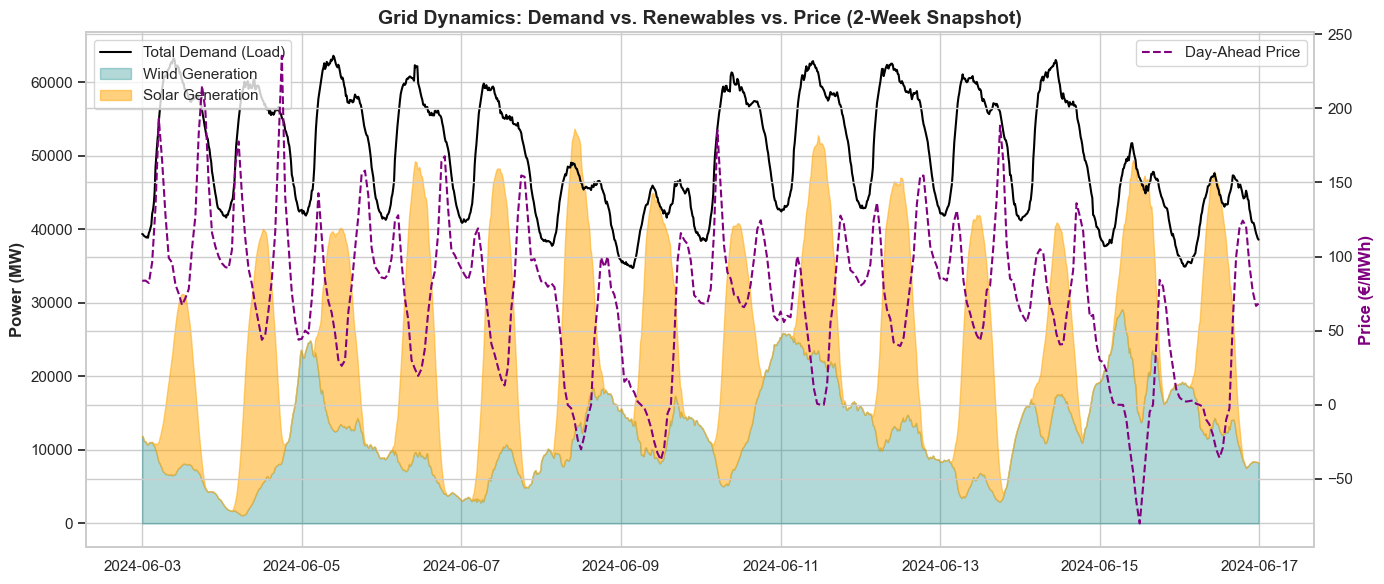

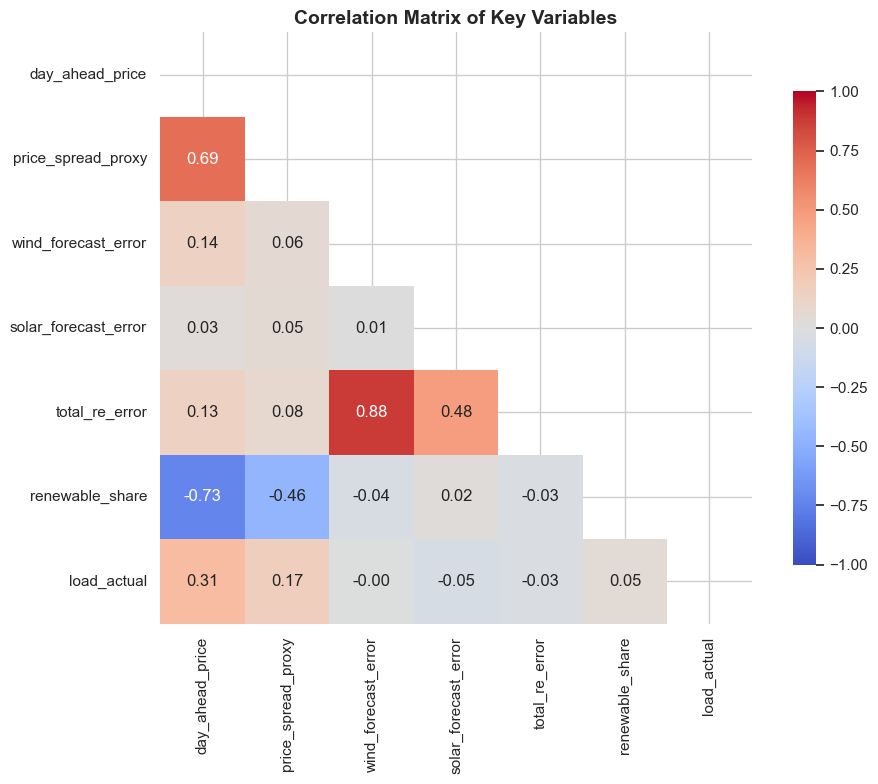

In [8]:
# EDA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- PLOT 1: The Physical Grid Dynamics ---
slice_df = df.loc['2024-06-03':'2024-06-16']

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Axis: Physical Power (MW)
ax1.plot(slice_df.index, slice_df['load_actual'], color='black', linewidth=1.5, label='Total Demand (Load)')
ax1.fill_between(slice_df.index, 0, slice_df['wind_actual_total'], color='teal', alpha=0.3, label='Wind Generation')
ax1.fill_between(slice_df.index, slice_df['wind_actual_total'], 
                 slice_df['wind_actual_total'] + slice_df['solar_actual'], 
                 color='orange', alpha=0.5, label='Solar Generation')
ax1.set_ylabel("Power (MW)", fontsize=12, fontweight='bold')
ax1.set_title("Grid Dynamics: Demand vs. Renewables vs. Price (2-Week Snapshot)", fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# Right Axis: Financial Market (€/MWh)
ax2 = ax1.twinx()
ax2.plot(slice_df.index, slice_df['day_ahead_price'], color='purple', linestyle='--', linewidth=1.5, label='Day-Ahead Price')
ax2.set_ylabel("Price (€/MWh)", color='purple', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- PLOT 2: Machine Learning Feature Correlation Heatmap ---
plt.figure(figsize=(10, 8))

# Selecting only the core variables to keep the plot clean
core_cols = [
    'day_ahead_price', 'price_spread_proxy', 'wind_forecast_error', 
    'solar_forecast_error', 'total_re_error', 'renewable_share', 'load_actual'
]
corr_matrix = df[core_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    fmt=".2f", 
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation Matrix of Key Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:* We will use a DAG to formalize our structural assumptions and apply backdoor adjustment to block observable confounders (e.g., `load_actual`, `load_forecast_error`, `hour`, `month`). This allows us to isolate the pure causal effect of renewable forecast errors (`total_re_error`) on market stress (`price_spread_proxy`).

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [ ] Logistic regression
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [x] Other: Gradient Boosting (XGBoost)

*Justification:* Energy markets exhibit extreme non-linearities (e.g., prices only crash into the negative when the renewable share crosses a specific threshold). Tree-based ensembles like Random Forest and XGBoost excel at capturing these non-linear thresholds and will be trained on lagged variables to predict price spreads one hour ahead.

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* We will deploy K-Means clustering to partition the 70,077 continuous intervals into distinct structural "grid regimes" (e.g., Winter Scarcity vs. Summer Oversupply). This will group observations based on multidimensional similarities (`renewable_share`, `load_actual`, `hour`) rather than financial metrics.

## 5. Evaluation Strategy

To ensure the mission's findings are both mathematically rigorous and economically meaningful, we will evaluate each block using distinct criteria:

**1. Baseline Benchmark:**
Before evaluating our advanced models, we will establish a baseline using a standard **Linear Regression (OLS)** model and a naive **Persistence Model** (predicting that the next hour's spread will equal the current hour's spread). Our machine learning models must significantly outperform these baselines to prove the value of non-linear algorithms in energy markets.

**2. Supervised Learning Evaluation (Regression):**
Because our target variable (`price_spread_proxy`) is continuous, this is a regression task. 
* **Primary Metric:** **RMSE (Root Mean Squared Error).** In wholesale energy markets, extreme price spikes cause severe financial damage. RMSE heavily penalizes large prediction errors, making it the ideal metric for stress forecasting.
* **Secondary Metrics:** **MAE (Mean Absolute Error)** for baseline accuracy, and **R² (Coefficient of Determination)** to measure the percentage of market volatility explained by our weather variables.

**3. Unsupervised Learning Evaluation (Clustering):**
* **Mathematical Validation:** We will use the **Silhouette Score** to evaluate the separation distance between the resulting K-Means clusters, and the **Elbow Method (Inertia)** to justify our selection of *k* clusters.
* **Domain Validation:** We will inspect the cluster centroids to ensure the mathematically derived regimes correspond to real-world grid physics (e.g., verifying that the cluster with the lowest renewable share and highest load corresponds to the highest average price spreads).

**4. Causal Inference Validation:**
To prove our causal estimates are robust, we will execute DoWhy refutation tests:
* **Random Common Cause / Unobserved Confounder Test:** Adding a simulated hidden variable to ensure our causal estimate does not drastically collapse.
* **Placebo Treatment Test:** Randomly shuffling the `total_re_error` variable. The causal effect should drop to zero, proving our original finding was not a statistical artifact.

## 6. Work Plan


| Step | Owner | Description |
|------|-------|-------------|
| 1 | All | Data collection & cleaning (ensuring 0-NaN integrity). |
| 2 | All | EDA: distributions, time-series visualization, and correlation matrix analysis. |
| 3 | Rohit | DAG construction in DoWhy, backdoor adjustment estimation, refutation tests, and ATE interpretation. |
| 4 | Armaan | Feature matrix assembly, train/test split, persistence model baseline, Random Forest/XGBoost training, and RMSE/R² comparison. |
| 5 | Christy |Feature standardization, K-Means clustering, silhouette score selection, centroid interpretation, and 2023 vs 2024 regime frequency analysis. |
| 6 | All | Sections 7–8: Synthesize findings across all three blocks, discuss causal vs. predictive limitations, and finalize notebook for submission. |

---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [9]:
# Causal inference analysis

### 7b. Supervised Learning

In [10]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [11]:
# Unsupervised / generative analysis

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
